In [7]:
import Pkg; Pkg.activate("../")
using NMRlab
using Plots
using TOML

  Activating project at `~/Source/NMRlab`


In [15]:
struct HamiltonianGenerator
    shiftRange::Vector{Float64}
    Jstd::Float64
    nCouplings::Int64
    baseFreq::Float64    
    shiftCtr::Float64


    function HamiltonianGenerator(toml_file::String)
        params = TOML.parsefile(toml_file)["Hamiltonian"]
        
        new(
            get(params,"shiftRange",[0.0,10.0]),
            get(params,"Jstd",5.0),
            get(params,"nCouplings",1),
            get(params,"baseFreq",600.0),
            get(params,"shiftCtr",4.76),
        )
    end
end

function (c::HamiltonianGenerator)(nspin::Integer)
    # Example callable behavior based on the parameters from the .toml file
    # Customize this function according to your needs

        # For illustration, let's assume the .toml file has a key "factor"

       # function randomHamiltonian(nspin::Integer,freq=600.,ctr=4.76,Jstd=10,shiftMax=10.0)
        # select some random chemical shifts
        
        chem_shifts = (c.shiftRange[2]-c.shiftRange[1]) .* rand(nspin) .+ c.shiftRange[1]
        H=sum(j->2pi*c.baseFreq*(chem_shifts[j]-c.shiftCtr)*SpinSim.SpinOp(nspin,SpinSim.Sz,j),1:nspin)

        # and some random couplings
        for j=1:rand(1:c.nCouplings*nspin*(nspin-1))
            k=rand(1:nspin)
            l=rand(1:nspin)
            if k==l continue end
            if k>l f=l; l=k; k=f; end
            J=c.Jstd*randn() # we use a normal distribution with sigma=10 Hz
            H.+=2pi*J*SpinSim.OpJstrong(nspin,k,l)
        end
        H
    end

In [9]:
hc = HamiltonianGenerator("hamiltonian.toml")

HamiltonianGenerator([0.0, 10.0], 12.0, 2, 600.0, 4.76)

In [22]:
n=8
H=hc(n)

256×256 SparseMatrixCSC{Float64, Int64} with 1920 stored entries:
⎡⢵⣷⢼⣦⡀⣦⣀⠀⠀⠀⠢⣀⠀⠀⠀⠀⠀⠀⠀⠀⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠲⣷⣕⣽⣟⠈⠛⢣⡀⠀⢦⡀⠣⡀⠀⠀⠀⠀⠀⠀⢦⡈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠠⣬⡛⠙⠑⢄⣄⣨⡻⠷⠀⠈⠆⠈⠱⡀⠀⠀⠀⠀⠀⠙⠆⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠘⠿⣀⡀⣹⣟⢝⢿⣦⠀⠀⠀⠀⠀⡈⠲⣀⠀⠀⠀⠀⠀⠀⠀⡈⠢⣀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠈⢿⡎⠻⣷⣿⢟⠀⠀⠀⠀⠀⠈⢢⡈⠢⡀⠀⠀⠀⠀⠀⠙⢦⡈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠈⢢⠈⠳⡀⠀⠀⠀⠀⠀⢵⣷⢾⣦⡀⣧⣀⠁⠀⠈⠑⣄⠀⠀⠀⠀⠀⠁⠀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠉⠢⡈⠁⠀⠀⠀⠀⠺⣷⣕⣽⣭⠈⠉⢱⡀⠀⠀⠈⠑⣄⠀⠀⠀⠀⠀⠐⢦⡈⠣⡀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠑⠢⡀⠠⡀⠀⠤⣬⡃⠛⠑⢄⣄⢨⡛⠒⠀⠀⠀⠈⠓⣄⠀⠀⠀⠀⠀⠙⠂⠈⠢⡀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠘⢢⡈⠲⠄⠘⢇⣀⡀⣙⣟⢝⢿⠦⠀⠀⠀⠀⠀⠈⠓⢄⠀⠀⠀⠀⠀⠀⢀⡈⠢⡀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠀⠀⠈⢻⠈⠻⡗⢿⢗⠀⠀⠀⠀⠀⠀⠀⠈⠓⢄⠀⠀⠀⠀⠀⠙⢦⡈⠢⡀⎥
⎢⠈⠢⡈⠳⣄⠀⠀⠀⠀⠀⠑⢤⡀⠀⠀⠀⠀⠀⠀⠀⢵⣷⢼⣦⡀⣧⡀⠀⠀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠈⠢⡈⠁⠀⠀⠀⠀⠀⠀⠑⢤⡀⠀⠀⠀⠀⠀⠲⣷⣕⣽⣍⠈⠉⢱⡄⠐⠦⡈⠣⡄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠈⠢⡀⠠⣄⠀⠀⠀⠀⠀⠙⢤⡀⠀⠀⠀⠤⣬⡃⠙⠑⢄⣤⢨⡛⠒⠀⠈⠂⠈⠢⢄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠈⢢⡈⠳⠄⠀⠀⠀⠀⠀⠙⢄⡀⠀⠀⠈⢇⣀⡀⣛⣟⢝⢿⡦⠀⠀⠀⠀⢀⡈⠢⣀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠀⢀⠀⠀⠀⠀⠀⠙⢄⡀⠀⢀⠉⢻⠈⠻⡷⢿⢗⠀⠀⠀⠀⠀⠈⢦⡀⠣⡀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡈⠳⣄⠀⠀⠀⠀⠀⠈⠢⡈⠣⡀⠀⠀⠀⠀⠀⣵⣿⢿⣦⡸⣷⡀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠢⡈⠀⠀⠀⠀⠀⠀⠀⠉⠦⡈⠀⠀⠀⠀⠀⠻⣷⣕⣽⣏⠈⠉⣶⡄⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠰⣄⠀⠀⠀⠀⠀⠈⢆⡀⠰⡀⠀⢶⣮⡋⠙⠑⢄⣄⣬⡛⠂⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡈⠳⠀⠀⠀⠀⠀⠀⠈⢢⠈⠳⠀⠈⢣⣤⡀⣽⣟⢝⢿⠦⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⠀⠀⠀⠀⠀⠀⠀⠀⠉⠢⠀⠀⠀⠉⠻⠈⠻⡗⢿⢗⎦

In [23]:
using LinearAlgebra
using SparseArrays

δt = π/2 / opnorm(H,Inf)
P=SpinSim.expm(-im*δt*(H))
rho0=sum(SpinSim.SpinOp(n,SpinSim.Sx,k) for k=1:n)
Fp=sum(SpinSim.SpinOp(n,SpinSim.Sp,k) for k=1:n)
fid = ComplexF64[]
sizehint!(fid,2<<14)
ρ = rho0
for k=1:2<<14
    push!(fid, tr(ρ*Fp)*exp(-2*π*k*δt))
    ρ = P'*ρ*P
    droptol!(ρ,10*eps(Float64))
end

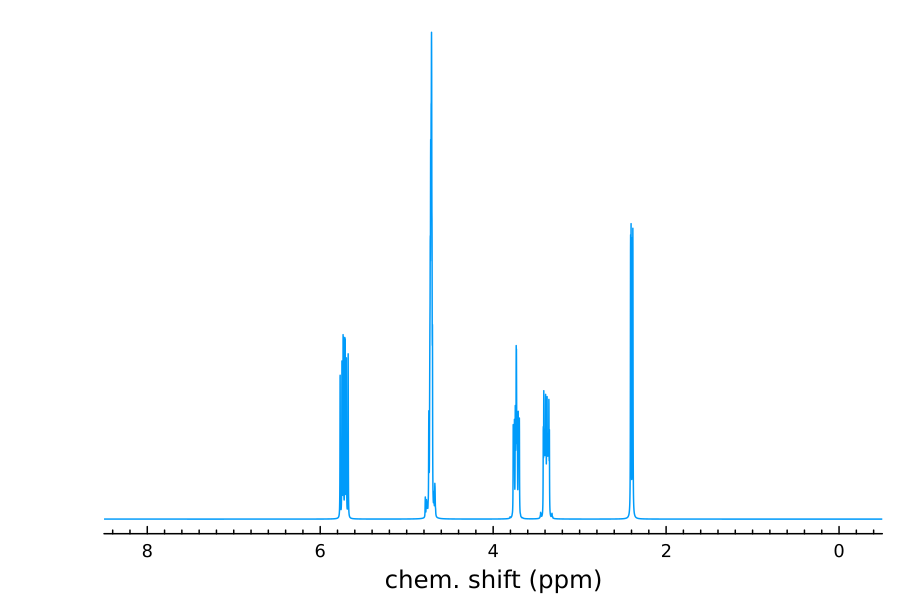

In [25]:
using FFTW
plot(range(-0.5/δt,stop=0.5/δt,length=length(fid))/600.0.+4.78, 
            real.(fftshift(fft(fid))),
            xaxis=:flip,
            minorticks=10,
            xlabel="chem. shift (ppm)",
            xlims=[-0.5,8.5],
            yaxis=false,
            grid=false,
            legend=false,
            fmt=:svg,dpi=150,
)